You'll hear some version of this sentence on rounds, in notes, and in discussion:

> "The test is 90% sensitive, so there's about a 10% chance we missed it..."

To be specific, this is often after a patient tested negative for something.


It sounds reasonable, and is the worst and most dangerous kind of true: *technically true*. It is the definition of sensitivity and the false negative rate, as many of us are taught in medical school:

$$
\text{Sensitivity} = \frac{\text{sick patients who test positive}}{\text{all sick patients}} = \frac{TP}{TP + FN}
$$

$$
\text{False negative rate} = \frac{\text{sick patients who test negative}}{\text{all sick patients}} = \frac{FN}{TP + FN} = 1 - \text{Sensitivity}
$$

*(TP = true positives, the sick patients the test catches; FN = false negatives, the sick patients it misses.)*

I once heard this during rounds, as a 4th year medical student. I should admit, at the time I knew it was wrong, but I didn't have the courage to say anything. There were two reasons:


1) I was a medical student (those of you who remember being one will understand)
2) I wasn't prepared to answer the next question effectively and succinctly: **Why?**

   

Because it answers the wrong question. The 10% describes *sick* patients: of everyone who has the disease, 1 in 10 tests negative. But after a negative result, we don't know our patient is sick; the question that matters is *of everyone who tests negative, how many are actually sick?*  Depending on the patient in front of you, that can be a fraction of a percent or more than one in seven. The sentence quietly swaps those two questions, and that swap is one of the most common statistical errors in medicine.

This post untangles it. There's no heavy maths. The main tool is counting: imagine 1,000 patients, and follow them through the test. A little Python does the counting for us, and you can skip the code entirely and still follow every step.

**What you'll come away with**

1. What sensitivity and specificity actually measure, and what they don't.
2. The two numbers you really want at the bedside (PPV and NPV), and why they depend on who you're testing.
3. A shortcut clinicians can use mentally: likelihood ratios.
4. Why the test's own numbers come with uncertainty of their own.
5. A short glossary of phrases to retire.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

rng = np.random.default_rng(42)
pd.set_option("display.precision", 3)
plt.rcParams["figure.figsize"] = (7, 4)

# Chart colours that match the blog's dark (Superhero) theme
# PANEL is a lighter navy at 55% opacity, so the page background shows through slightly
PANEL, LEGEND = "#2b4c6f8c", "#254464"
INK, MUTED, GRID = "#ebebeb", "#a9b3bd", "#3d5a78"
PALETTE = ["#df6919", "#5bc0de", "#5cb85c", "#ffc107", "#d9534f", "#4c9be8"]
plt.rcParams.update({
    "figure.facecolor": PANEL, "axes.facecolor": "none", "savefig.facecolor": PANEL,
    "text.color": INK, "axes.labelcolor": INK, "axes.titlecolor": INK,
    "xtick.color": MUTED, "ytick.color": MUTED, "axes.edgecolor": GRID, "grid.color": GRID,
    "legend.facecolor": LEGEND, "legend.edgecolor": GRID, "legend.labelcolor": INK,
    "axes.prop_cycle": plt.cycler(color=PALETTE),
    "boxplot.boxprops.color": INK, "boxplot.whiskerprops.color": INK, "boxplot.capprops.color": INK,
    "boxplot.medianprops.color": PALETTE[0], "boxplot.flierprops.markeredgecolor": MUTED,
})

## 1. Two questions that sound alike

Sensitivity and specificity describe the **test**. They answer questions that start from the patient's true condition:

- **Sensitivity:** *of the people who have the disease*, what fraction test positive?
- **Specificity:** *of the people who don't have the disease*, what fraction test negative?

Now this presupposed you have the ground truth about whether or not the patient has a disease. As a clinician, this is not the information we have, it's the information *we want*. We should ask the reverse question:

- **Positive predictive value (PPV):** *of the people who test positive*, what fraction have the disease?
- **Negative predictive value (NPV):** *of the people who test negative*, what fraction are disease-free?

"90% sensitive" means that 10% of people **with** the disease test negative. It says nothing directly about how likely your patient is to have it. 

To answer that, you need one more ingredient: how likely the disease was *before* you tested. Clinicians call this the **pre-test probability**; in a population it's the **prevalence**. Typically, we aren't walking around with the prevalence of diseases in our heads (some brilliant physicians are exempt, of course).

## 2. Follow 1,000 patients through the test

Take a test with **90% sensitivity** and **95% specificity**, and use it in a clinic where **2%** of the patients tested actually have the disease. Instead of percentages, count people.

In [2]:
def follow_patients(pretest, sensitivity, specificity, n=1000):
    """Expected counts when n patients with a given pre-test probability are tested."""
    sick = n * pretest
    well = n - sick
    table = pd.DataFrame(
        {"Test positive": [sick * sensitivity, well * (1 - specificity)],
         "Test negative": [sick * (1 - sensitivity), well * specificity]},
        index=["Has the disease", "Doesn't have it"])
    table["Total"] = table.sum(axis=1)
    table.loc["Total"] = table.sum()
    return table

table = follow_patients(pretest=0.02, sensitivity=0.90, specificity=0.95)
table.round(1)

,Test positive,Test negative,Total
Has the disease,18.0,2.0,20.0
Doesn't have it,49.0,931.0,980.0
Total,67.0,933.0,1000.0


Read the table one row at a time and then one column at a time.

- **Rows (what the test does):** of the 20 people with the disease, 18 test positive, which is the 90% sensitivity. Of the 980 without it, 931 test negative, which is the 95% specificity.
- **Columns (what you see):** 67 people test positive. Only 18 of them have the disease. The other 49 are false alarms from the much larger healthy group.

So a positive result means a 27% chance of disease, not 90%. A negative result leaves a 2 in 933 chance, about 0.2%. In this clinic, a negative result is wrong far less often than 1 time in 10.

**Four names, two denominators.** The "10% chance we missed it" and the number you actually need after a negative test both start from the same 2 missed patients in the table. What changes is what you divide by:

| Name | Share of… | Formula | In this clinic |
|---|---|---|---|
| Sensitivity | sick patients who test positive | TP / (TP + FN) | 18 / 20 = 90% |
| False negative rate | sick patients who test negative | FN / (TP + FN) | 2 / 20 = 10% |
| Negative predictive value (NPV) | negative tests that are truly disease-free | TN / (FN + TN) | 931 / 933 = 99.8% |
| False omission rate (1 − NPV) | negative tests that are actually sick | FN / (FN + TN) | 2 / 933 = 0.2% |

*(TN = true negatives, the healthy patients who test negative.)*

"10% chance we missed it" is the false negative rate. It's correct, but it describes patients we already know are sick. After a negative test, the number we want is the false omission rate. In this clinic it's about fifty times smaller, and Section 3 shows it can also be larger.

A warning about the names: some older textbooks and papers use "false negative rate" loosely to mean the false omission rate, which adds to the confusion. When it matters, say the denominator out loud: "10% *of sick patients* test negative" versus "0.2% *of negative tests* are wrong".

In [3]:
def predictive_values(pretest, sensitivity, specificity):
    """PPV and NPV from Bayes' theorem."""
    true_pos = pretest * sensitivity
    false_pos = (1 - pretest) * (1 - specificity)
    true_neg = (1 - pretest) * specificity
    false_neg = pretest * (1 - sensitivity)
    return true_pos / (true_pos + false_pos), true_neg / (true_neg + false_neg)

ppv, npv = predictive_values(0.02, 0.90, 0.95)
print(f"PPV: {ppv:.1%} of positives have the disease")
print(f"NPV: {npv:.1%} of negatives are disease-free, so {1 - npv:.2%} of negatives are missed cases")

PPV: 26.9% of positives have the disease
NPV: 99.8% of negatives are disease-free, so 0.21% of negatives are missed cases


That function is just Bayes' theorem written as counting:

$$\text{PPV} = \frac{\text{true positives}}{\text{all positives}} = \frac{p \cdot \text{sens}}{p \cdot \text{sens} + (1-p)(1-\text{spec})},$$

where $p$ is the pre-test probability. Notice that $p$ appears in every term. Change who you test, and the PPV changes even though the test hasn't.

## 3. Same test, different patients

The test's sensitivity and specificity stay the same whether you use it on a well person at a screening fair or on a patient you already strongly suspect. The predictive values don't.

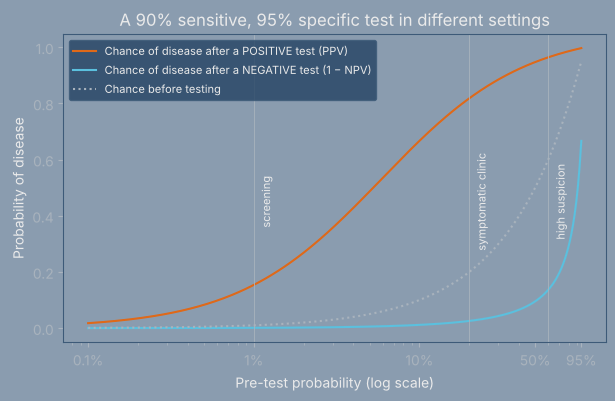

In [4]:
pretest = np.geomspace(0.001, 0.95, 300)
ppv, npv = predictive_values(pretest, 0.90, 0.95)

fig, ax = plt.subplots()
ax.plot(pretest, ppv, label="Chance of disease after a POSITIVE test (PPV)")
ax.plot(pretest, 1 - npv, label="Chance of disease after a NEGATIVE test (1 − NPV)")
ax.plot(pretest, pretest, color=MUTED, ls=":", label="Chance before testing")
for p, where in [(0.01, "screening"), (0.2, "symptomatic clinic"), (0.6, "high suspicion")]:
    ax.axvline(p, color=MUTED, lw=0.6)
    ax.text(p * 1.08, 0.45, where, fontsize=8, rotation=90, va="center")
ax.set_xscale("log")
ax.set_xticks([0.001, 0.01, 0.1, 0.5, 0.95], labels=["0.1%", "1%", "10%", "50%", "95%"])
ax.set_xlabel("Pre-test probability (log scale)")
ax.set_ylabel("Probability of disease")
ax.set_title("A 90% sensitive, 95% specific test in different settings")
ax.legend(fontsize=8, loc="upper left")
plt.show()

In [5]:
rows = []
for setting, p in [("Screening the general population", 0.01),
                   ("Symptomatic clinic", 0.20),
                   ("High clinical suspicion", 0.60)]:
    ppv, npv = predictive_values(p, 0.90, 0.95)
    rows.append({"Setting": setting, "Before testing": p,
                 "After positive (PPV)": ppv, "After negative (1 − NPV)": 1 - npv})
pd.DataFrame(rows).style.format({c: "{:.1%}" for c in ["Before testing", "After positive (PPV)", "After negative (1 − NPV)"]}).hide(axis="index")

Setting,Before testing,After positive (PPV),After negative (1 − NPV)
Screening the general population,1.0%,15.4%,0.1%
Symptomatic clinic,20.0%,81.8%,2.6%
High clinical suspicion,60.0%,96.4%,13.6%


The same test result means very different things:

- **Screening:** most positives are false alarms (PPV about 15%). A positive result calls for confirmation, not a diagnosis.
- **High suspicion:** a negative result still leaves about a 1 in 7 chance of disease. That's far too high to "rule out" anything, even though the test is "90% sensitive".

That second point is the real danger in our opening sentence. The 10% figure doesn't tell you the chance your patient is sick. It tells you how often the test misses people who *are* sick, and when you're testing someone you already suspect, those misses add up.

## 4. Doctors find this hard, and that's not a personal failing

In a well-known study, Gerd Gigerenzer gave 160 gynecologists this problem about mammography screening:

> About 1% of women screened have breast cancer. If a woman has breast cancer, the probability that she tests positive is 90%. If she doesn't, the probability that she still tests positive is 9%. A woman tests positive. What is the probability she actually has breast cancer?

Most of them (about 60%, a little over half) answered 80–90%. Only one in five chose the correct answer, about 10% probability. After a short training session that taught them to think in counts ("natural frequencies") instead of percentages, 87% got problems like this right.

Here are those 1,000 women, as a picture.

Chance of cancer after a positive mammogram: 9 / 98 = 9%


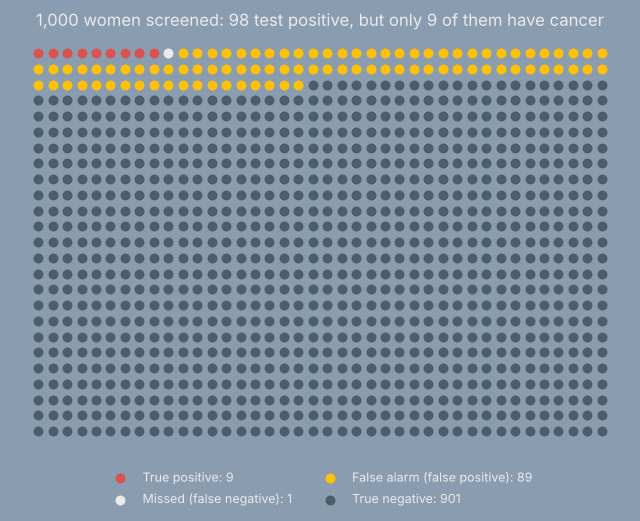

In [6]:
counts = follow_patients(pretest=0.01, sensitivity=0.90, specificity=0.91)
tp = round(counts.loc["Has the disease", "Test positive"])     # 9
fn = round(counts.loc["Has the disease", "Test negative"])     # 1
fp = round(counts.loc["Doesn't have it", "Test positive"])     # 89
tn = 1000 - tp - fn - fp

groups = (["True positive"] * tp + ["Missed (false negative)"] * fn
          + ["False alarm (false positive)"] * fp + ["True negative"] * tn)
colours = {"True positive": "#d9534f", "Missed (false negative)": INK,
           "False alarm (false positive)": "#ffc107", "True negative": "#4e5d6c"}
xs, ys = np.meshgrid(np.arange(40), np.arange(25))
xs, ys = xs.ravel(), ys.ravel()[::-1]

fig, ax = plt.subplots(figsize=(8, 5.4))
for g, col in colours.items():
    idx = [i for i, grp in enumerate(groups) if grp == g]
    n_g = len(idx)
    ax.scatter(xs[idx], ys[idx], s=38, color=col, label=f"{g}: {n_g}")
ax.set_axis_off()
ax.set_title(f"1,000 women screened: {tp + fp} test positive, but only {tp} of them have cancer")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.02), ncol=2, frameon=False, fontsize=9)
plt.show()
print(f"Chance of cancer after a positive mammogram: {tp} / {tp + fp} = {tp / (tp + fp):.0%}")

Seen this way, the answer is hard to miss: the few true positives are swamped by false alarms from the 990 healthy women, because 9% of a big number is bigger than 90% of a small one.

**The habit worth building:** when you meet a test statistic, translate it into "out of 1,000 people like my patient, how many…?" before you interpret it. 

If you need to pull out your phone's calculator and draw the 2 x 2 table, do it. It's worth it.

## 5. A bedside shortcut: likelihood ratios

Redrawing a table for every patient is slow. **Likelihood ratios** package a test's sensitivity and specificity into one number per result:

- **LR+** = sensitivity ÷ (1 − specificity): how much a positive result multiplies the odds of disease.
- **LR−** = (1 − sensitivity) ÷ specificity: how much a negative result multiplies them.

The rule is simple: **post-test odds = pre-test odds × likelihood ratio**, where odds = p ÷ (1 − p). For our test, LR+ = 0.90 ÷ 0.05 = 18 and LR− = 0.10 ÷ 0.95 ≈ 0.11. A rough guide often taught: LRs above 10 or below 0.1 change the picture a lot; values between about 0.5 and 2 barely change it.

In [7]:
def post_test_probability(pretest, likelihood_ratio):
    odds = pretest / (1 - pretest)
    post_odds = odds * likelihood_ratio
    return post_odds / (1 + post_odds)

sens, spec = 0.90, 0.95
lr_pos, lr_neg = sens / (1 - spec), (1 - sens) / spec
print(f"LR+ = {lr_pos:.1f}, LR- = {lr_neg:.3f}")

rows = []
for p in [0.01, 0.05, 0.20, 0.50, 0.80]:
    rows.append({"Pre-test": p,
                 "After positive": post_test_probability(p, lr_pos),
                 "After negative": post_test_probability(p, lr_neg)})
pd.DataFrame(rows).style.format("{:.1%}").hide(axis="index")

LR+ = 18.0, LR- = 0.105


Pre-test,After positive,After negative
1.0%,15.4%,0.1%
5.0%,48.6%,0.6%
20.0%,81.8%,2.6%
50.0%,94.7%,9.5%
80.0%,98.6%,29.6%


These match the PPV and 1 − NPV values from Section 3, because they are the same calculation in a different form. The advantage is that likelihood ratios chain: if two tests are genuinely independent given the disease status, you can multiply the odds by one LR and then the other. (In practice tests often aren't independent, for example two imaging studies that miss the same small lesions, so chaining overstates certainty. Repeating the same test is the extreme case.)

The likelihood ratio is also known as the **Bayes Factor**. Different name, same principle: *Given a test result*, how much *more or less* likely is the patient to have a disease. 3Blue1Brown of Youtube fame has [a great video](https://www.youtube.com/watch?v=lG4VkPoG3ko){target="_blank"} on it. As mentioned above, I'm not typically walking around with a disease prevalence memorized, and so I often cannot compute PPV/NPV explicitly. But knowing sensitivity and specificity lets me estimate the likelikehood ratio or Bayes factor, and lets me discuss a patient's relative risk with a test result.

## 6. Checking the maths by simulation

A theme of this blog is that a computer lets you check a formula instead of trusting it. Simulate 200,000 patients one by one, each with a 20% pre-test probability, run each through a 90%/95% test, and simply count.

In [8]:
n = 200_000
has_disease = rng.random(n) < 0.20
test_positive = np.where(has_disease, rng.random(n) < 0.90, rng.random(n) < 0.05)

simulated_ppv = has_disease[test_positive].mean()
simulated_miss = has_disease[~test_positive].mean()
formula_ppv, formula_npv = predictive_values(0.20, 0.90, 0.95)
print(f"PPV:     simulated {simulated_ppv:.3f}   formula {formula_ppv:.3f}")
print(f"1 - NPV: simulated {simulated_miss:.4f}  formula {1 - formula_npv:.4f}")

PPV:     simulated 0.818   formula 0.818
1 - NPV: simulated 0.0260  formula 0.0256


Counting simulated patients gives the same answer as Bayes' theorem, to within simulation noise. When a formula feels slippery, simulating it is often the quickest way to build trust, or to find a mistake.

## 7. The test's numbers are estimates too

"90% sensitivity" usually comes from a validation study, often a modest one. Suppose it found:

- 45 of 50 patients with the disease tested positive (90% sensitivity);
- 190 of 200 patients without it tested negative (95% specificity).

Those are estimates from 250 people, not fixed facts. A natural way to express the uncertainty is a **beta distribution** for each: with a flat starting point, sensitivity is Beta(45 + 1, 5 + 1) and specificity Beta(190 + 1, 10 + 1). (This is the standard Bayesian updating rule for proportions: add the successes to α and the failures to β. Future posts will build on it.) Then simulate: draw a plausible sensitivity and specificity, compute the PPV, and repeat.

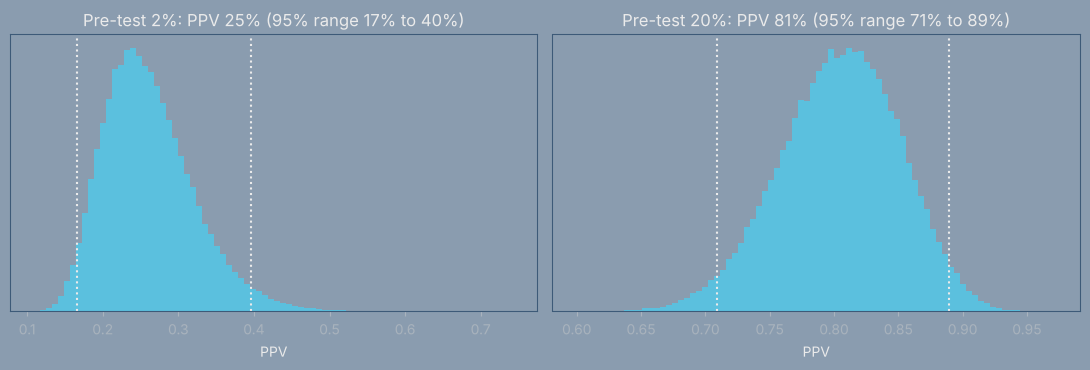

In [9]:
draws = 100_000
sens_draws = rng.beta(45 + 1, 5 + 1, draws)
spec_draws = rng.beta(190 + 1, 10 + 1, draws)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
for ax, pretest in zip(axes, [0.02, 0.20]):
    ppv_draws, _ = predictive_values(pretest, sens_draws, spec_draws)
    lo, mid, hi = np.percentile(ppv_draws, [2.5, 50, 97.5])
    ax.hist(ppv_draws, bins=80, color=PALETTE[1])
    ax.axvline(lo, color=INK, ls=":"); ax.axvline(hi, color=INK, ls=":")
    ax.set_title(f"Pre-test {pretest:.0%}: PPV {mid:.0%} (95% range {lo:.0%} to {hi:.0%})")
    ax.set_xlabel("PPV")
    ax.set_yticks([])
plt.tight_layout()
plt.show()

With a 2% pre-test probability, the PPV could plausibly be anywhere from about 17% to 40%. Most of that range comes from the specificity: when almost everyone tested is healthy, small changes in the false-positive rate swing the answer. With a 20% pre-test probability the range (about 71% to 89%) is narrower in relative terms.

Two practical lessons:

- **Check where a test's numbers come from.** Ask how many patients they're based on and who those patients were. A test validated in a hospital population (sicker, more obvious cases) often looks better than it performs in primary care. This is known as *spectrum bias*.
- **Small validation studies mean wide uncertainty, especially in screening.** Quoting a single PPV to one decimal place can imply far more precision than exists.

## 8. Phrases to retire, and what to say instead

| You might hear | What's wrong | Better |
|---|---|---|
| "The test was negative and it's 90% sensitive, so there's a 10% chance it's a false negative." | The chance that a *negative result* is wrong (1 − NPV) depends on the pre-test probability. It can be far below or far above 10%. | "Given how likely this was beforehand, the chance of disease after a negative test is about X%." |
| "It's 95% specific, so a positive means 95% likely." | That's the PPV, and at low prevalence it can be much lower. | "In this population, roughly X of every 100 positives are true." |
| "The test is 95% accurate." | Accuracy mixes both groups and depends heavily on prevalence. At 2% prevalence, a "test" that calls everyone negative is 98% accurate. | Report sensitivity and specificity, or the predictive values for the population in question. |
| "SnNout / SpPin: a negative highly sensitive test rules it out." | Useful, but only when sensitivity is *very* high and the pre-test probability isn't. Section 3 shows a 90% sensitive test failing to rule out at high suspicion. | Use the likelihood ratio and the pre-test probability. |
| "Let's repeat it to be sure." | Repeating the same test often repeats the same error. Results aren't independent. | Confirm with a *different* test that fails in different ways. |

## Takeaways

- Sensitivity and specificity describe the **test**; PPV and NPV describe **your patient's result**. Converting from one to the other needs the pre-test probability.
- The same test can produce a PPV of 15% or 96% depending on who you test.
- Likewise, the chance that a negative result is wrong can be 0.1% in screening or about 14% under high suspicion. That's the number the "10% chance we missed it" sentence is really reaching for.
- Thinking in counts ("out of 1,000 patients like this one…") turns a confusing probability problem into arithmetic.
- Likelihood ratios aka the Bayes Factor give a bedside shortcut: multiply the pre-test odds.
- The test's own numbers are estimates, and their uncertainty can matter a lot, most of all in screening.

The deeper idea is Bayesian: start with what you believed before the test, and update it by how much more likely the result is in disease than in health. Future posts build the same habit with other examples, from baseball batting averages to trading-card pull rates.

## References and further reading

- Gigerenzer G, Gaissmaier W, Kurz-Milcke E, Schwartz LM, Woloshin S. Helping doctors and patients make sense of health statistics. *Psychological Science in the Public Interest*. 2007;8(2):53–96.
- Gigerenzer G. What are natural frequencies? *BMJ*. 2011;343:d6386.
- Altman DG, Bland JM. Diagnostic tests 1: sensitivity and specificity. *BMJ*. 1994;308:1552.
- Altman DG, Bland JM. Diagnostic tests 2: predictive values. *BMJ*. 1994;309:102.
- Deeks JJ, Altman DG. Diagnostic tests 4: likelihood ratios. *BMJ*. 2004;329:168–169.
- Fagan TJ. Nomogram for Bayes's theorem. *New England Journal of Medicine*. 1975;293:257.
- Whiting PF et al. Sources of variation and bias in studies of diagnostic accuracy: a systematic review. *Annals of Internal Medicine*. 2004;140(3):189–202 (spectrum bias and related problems).

*The test figures in this post (90% sensitivity, 95% specificity, and the validation counts) are illustrative, not taken from any particular test.*